## CIT651: Introduction to Machine Learning — Assignment 2



##### *Datasets: heteroscedastic.csv · monotonic.csv · titanic.csv · CIFAR-10 · heart.csv*

In [1]:
! wget -nc https://raw.githubusercontent.com/essawey/Assignment-2/refs/heads/main/heart.csv
! wget -nc https://raw.githubusercontent.com/essawey/Assignment-2/refs/heads/main/heteroscedastic.csv
! wget -nc https://raw.githubusercontent.com/essawey/Assignment-2/refs/heads/main/monotonic.csv
! wget -nc https://raw.githubusercontent.com/essawey/Assignment-2/refs/heads/main/titanic.csv

File ‘heart.csv’ already there; not retrieving.

File ‘heteroscedastic.csv’ already there; not retrieving.

File ‘monotonic.csv’ already there; not retrieving.

File ‘titanic.csv’ already there; not retrieving.



In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from datasets import load_dataset


from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, KFold
from sklearn.metrics import (mean_squared_error, r2_score, accuracy_score,
                             precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix)
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.cluster import KMeans
from sklearn.feature_selection import f_classif

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


---
# Part 1: Polynomial Regression, Regularization, and Model Analysis
> **Datasets:** `heteroscedastic.csv` and `monotonic.csv`

## 0. Data Loading

In [3]:
df_hetero = pd.read_csv('heteroscedastic.csv')
df_mono = pd.read_csv('monotonic.csv')

print("Heteroscedastic Dataset shape:", df_hetero.shape)
display(df_hetero.head())
print("\nMonotonic Dataset shape:", df_mono.shape)
display(df_mono.head())

Heteroscedastic Dataset shape: (300, 2)


,x,y
0,0.000000,-5.006572
1,0.334448,-4.650530
2,0.668896,-0.926905
3,1.003344,3.590906
4,1.337793,-0.092592



Monotonic Dataset shape: (300, 2)


,x,y
0,0.000000,-5.503286
1,0.334448,-3.831045
2,0.668896,-2.158804
3,1.003344,-0.486563
4,1.337793,1.185677


## 1. Exploratory Data Analysis (EDA)

#### 1A. Missing Values, Outliers, and Feature Distributions

In [4]:
print("="*25)
print("Heteroscedastic Dataset")
print("="*25)

display(df_hetero.describe())

print("Missing values:")
print(df_hetero.isnull().sum())

for col in df_hetero.columns:
    Q1, Q3 = df_hetero[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    n_out = ((df_hetero[col] < Q1 - 1.5 * IQR) | (df_hetero[col] > Q3 + 1.5 * IQR)).sum()
    print(f"  IQR outliers in '{col}': {n_out}")

Heteroscedastic Dataset


,x,y
count,300.000000,300.000000
mean,50.000000,245.430221
std,29.012294,158.837887
min,0.000000,-5.006572
25%,25.000000,117.194547
50%,50.000000,238.404158
75%,75.000000,357.031076
max,100.000000,675.784956


Missing values:
x    0
y    0
dtype: int64
  IQR outliers in 'x': 0
  IQR outliers in 'y': 0


In [5]:
print("="*25)
print("Monotonic Dataset")
print("="*25)

display(df_mono.describe())

print("Missing values:")
print(df_mono.isnull().sum())

for col in df_mono.columns:
    Q1, Q3 = df_mono[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    n_out = ((df_mono[col] < Q1 - 1.5 * IQR) | (df_mono[col] > Q3 + 1.5 * IQR)).sum()
    print(f"  IQR outliers in '{col}': {n_out}")

Monotonic Dataset


,x,y
count,300.000000,300.000000
mean,50.000000,244.496714
std,29.012294,145.061468
min,0.000000,-5.503286
25%,25.000000,119.496714
50%,50.000000,244.496714
75%,75.000000,369.496714
max,100.000000,494.496714


Missing values:
x    0
y    0
dtype: int64
  IQR outliers in 'x': 0
  IQR outliers in 'y': 0


#### 1B. Visualizations — Scatter Plots, Histograms, Box Plots

##### Heteroscedastic Plots

1. Scatter Plot


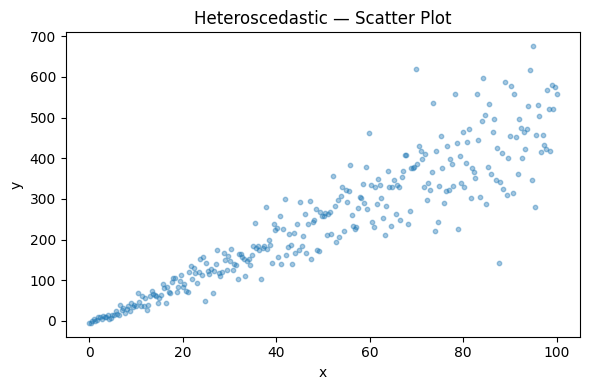

2. Histogram


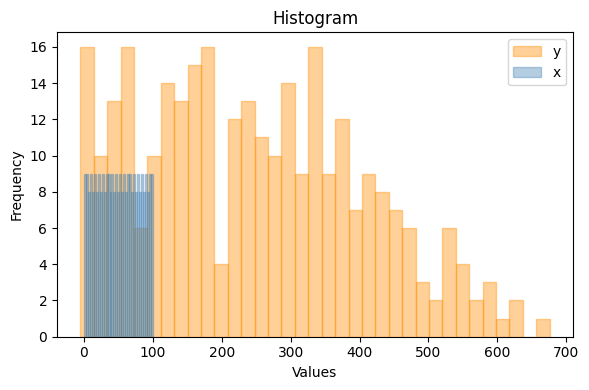

3. Box Plot


/tmp/ipykernel_47670/3235293264.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([df_hetero['x'], df_hetero['y']], labels=['x', 'y'], vert=False)


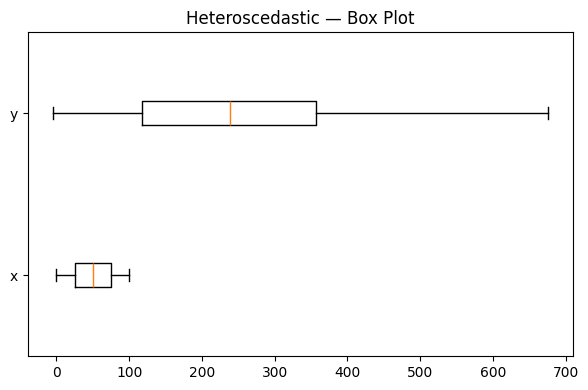

In [6]:
print("1. Scatter Plot")
plt.figure(figsize=(6, 4))
plt.scatter(df_hetero['x'], df_hetero['y'], alpha=0.4, s=10)
plt.title('Heteroscedastic — Scatter Plot')
plt.xlabel('x')
plt.ylabel('y')
plt.tight_layout()
plt.show()

print("2. Histogram")
plt.figure(figsize=(6, 4))
plt.hist(df_hetero['y'], bins=35, edgecolor='darkorange', color='darkorange', alpha=0.4, label='y')
plt.hist(df_hetero['x'], bins=35, edgecolor='steelblue', color='steelblue', alpha=0.4, label='x')
plt.title('Histogram')
plt.xlabel('Values')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()

print("3. Box Plot")
plt.figure(figsize=(6, 4))
plt.boxplot([df_hetero['x'], df_hetero['y']], labels=['x', 'y'], vert=False)
plt.title('Heteroscedastic — Box Plot')
plt.tight_layout()
plt.show()


##### Monotonic Plots

1. Scatter Plot


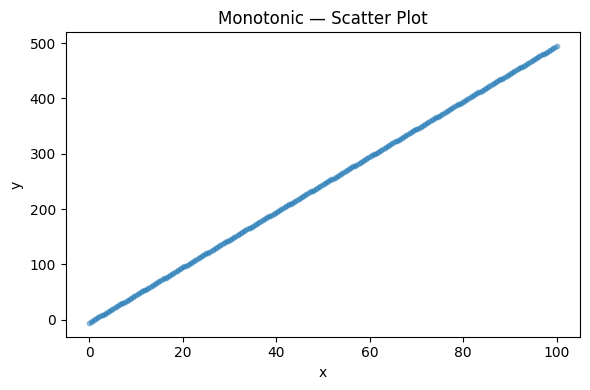

2. Histogram


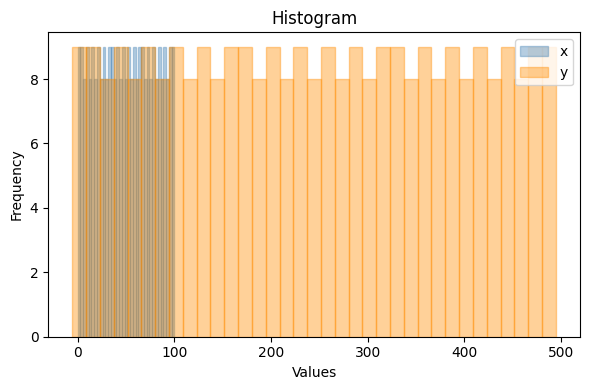

3. Box Plot


/tmp/ipykernel_47670/1454707513.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([df_mono['x'], df_mono['y']], labels=['x', 'y'], vert=False)


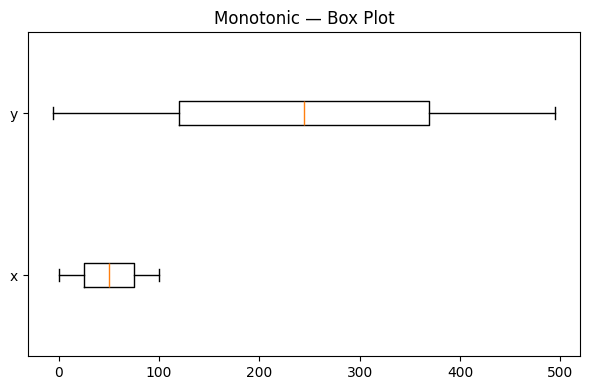

In [7]:
print("1. Scatter Plot")
plt.figure(figsize=(6, 4))
plt.scatter(df_mono['x'], df_mono['y'], alpha=0.4, s=10)
plt.title('Monotonic — Scatter Plot')
plt.xlabel('x')
plt.ylabel('y')
plt.tight_layout()
plt.show()

print("2. Histogram")
plt.figure(figsize=(6, 4))
plt.hist(df_mono['x'], bins=35, edgecolor='steelblue', color='steelblue', alpha=0.4, label='x')
plt.hist(df_mono['y'], bins=35, edgecolor='darkorange', color='darkorange', alpha=0.4, label='y')
plt.title('Histogram')
plt.xlabel('Values')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()

print("3. Box Plot")
plt.figure(figsize=(6, 4))
plt.boxplot([df_mono['x'], df_mono['y']], labels=['x', 'y'], vert=False)
plt.title('Monotonic — Box Plot')
plt.tight_layout()
plt.show()

#### 1C. Data Preprocessing
> Apply appropriate techniques based on EDA findings

In [8]:
X_hetero = df_hetero[['x']].values
y_hetero = df_hetero['y'].values
X_hetero_train, X_hetero_test, y_hetero_train, y_hetero_test = train_test_split(X_hetero, y_hetero, test_size=0.2)

X_mono = df_mono[['x']].values
y_mono = df_mono['y'].values
X_mono_train, X_mono_test, y_mono_train, y_mono_test = train_test_split(X_mono, y_mono, test_size=0.2)

In [9]:
print("Heteroscedastic")
print(f"Train: {X_hetero_train.shape}")
print(f"Test: {X_hetero_test.shape}")
print()
print("Monotonic")
print(f"Train: {X_mono_train.shape}")
print(f"Test: {X_mono_test.shape}")

Heteroscedastic
Train: (240, 1)
Test: (60, 1)

Monotonic
Train: (240, 1)
Test: (60, 1)


## 2. Polynomial Regression — Basic Implementation

#### 2A. Polynomial Regression — Degrees 3 and 4 (No Regularization)

##### Heteroscedastic

In [10]:
# 3rd degree heteroscedastic
pipe = make_pipeline(
    PolynomialFeatures(degree=3, include_bias=False),
    StandardScaler(),
    LinearRegression(),
)
pipe.fit(X_hetero_train, y_hetero_train)
results_hetero_3 = pipe

# 4th degree heteroscedastic
pipe = make_pipeline(
    PolynomialFeatures(degree=4, include_bias=False),
    StandardScaler(),
    LinearRegression(),
)
pipe.fit(X_hetero_train, y_hetero_train)
results_hetero_4 = pipe

##### Monotonic

In [11]:
# 3rd degree
pipe = make_pipeline(
    PolynomialFeatures(degree=3, include_bias=False),
    StandardScaler(),
    LinearRegression(),
)
pipe.fit(X_mono_train, y_mono_train)
results_mono_3 = pipe


# 4th degree
pipe = make_pipeline(
    PolynomialFeatures(degree=4, include_bias=False),
    StandardScaler(),
    LinearRegression(),
)
pipe.fit(X_mono_train, y_mono_train)
results_mono_4 = pipe

#### 2B. Performance Evaluation — RMSE and R² on Train and Test Sets

$$
\text{RMSE} = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}
$$
.
$$
R^2 = 1 - \frac{\sum(y_i - \hat{y}_i)^2}{\sum(y_i - \bar{y})^2}
$$

In [16]:
def evaluate(model, X_train, y_train, X_test, y_test):
    return {
        'RMSE_train': np.sqrt(mean_squared_error(X_train, model.predict(X_train))),
        'RMSE_test': np.sqrt(mean_squared_error(y_test, model.predict(X_test))),
        'R2_train': r2_score(y_train, model.predict(X_train)),
        'R2_test': r2_score(y_test, model.predict(X_test)),
    }


rows = []

# Heteroscedastic
m = evaluate(results_hetero_3, X_hetero_train, y_hetero_train, X_hetero_test, y_hetero_test)
rows.append({"Dataset": "Heteroscedastic", "Degree": 3, **m})

m = evaluate(results_hetero_4, X_hetero_train, y_hetero_train, X_hetero_test, y_hetero_test)
rows.append({"Dataset": "Heteroscedastic", "Degree": 4, **m})

# Monotonic
m = evaluate(results_mono_3, X_mono_train, y_mono_train, X_mono_test, y_mono_test)
rows.append({"Dataset": "Monotonic", "Degree": 3, **m})

m = evaluate(results_mono_4, X_mono_train, y_mono_train, X_mono_test, y_mono_test)
rows.append({"Dataset": "Monotonic", "Degree": 4, **m})


df_poly_metrics = round(pd.DataFrame(rows), 4)
display(df_poly_metrics)

,Dataset,Degree,RMSE_train,RMSE_test,R2_train,R2_test
0,Heteroscedastic,3,231.1319,58.3229,0.8500,0.8644
1,Heteroscedastic,4,231.1842,58.4964,0.8509,0.8636
2,Monotonic,3,225.2493,0.0000,1.0000,1.0000
3,Monotonic,4,225.2493,0.0000,1.0000,1.0000


#### 2C. Overfitting Analysis — Regression Curves and Metric Comparison

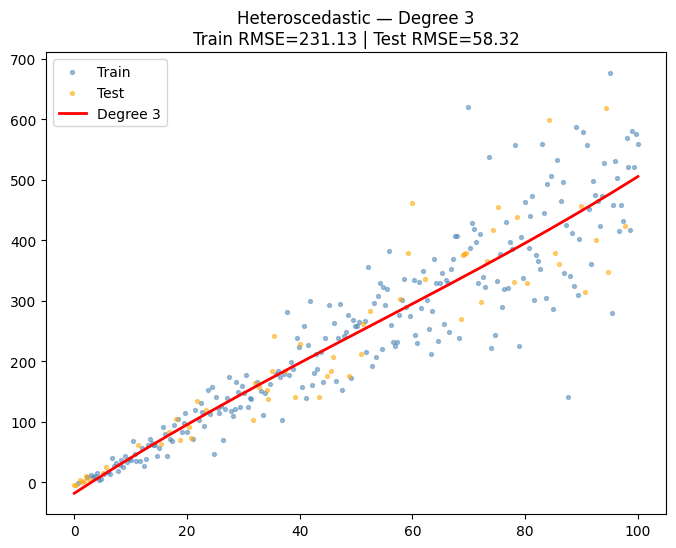

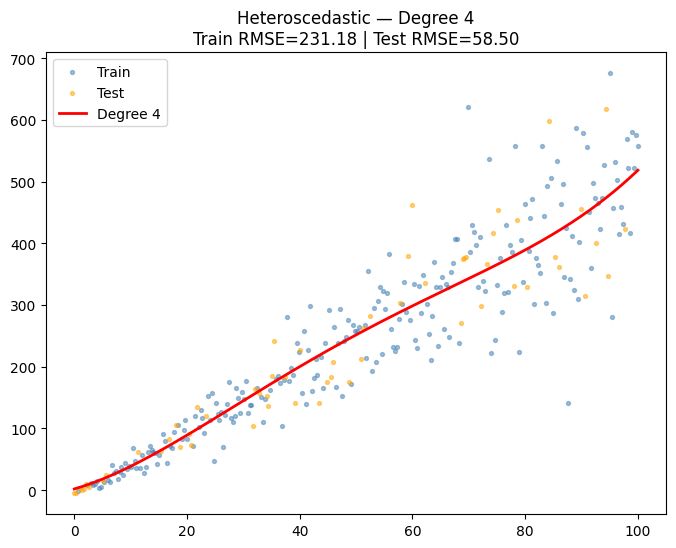

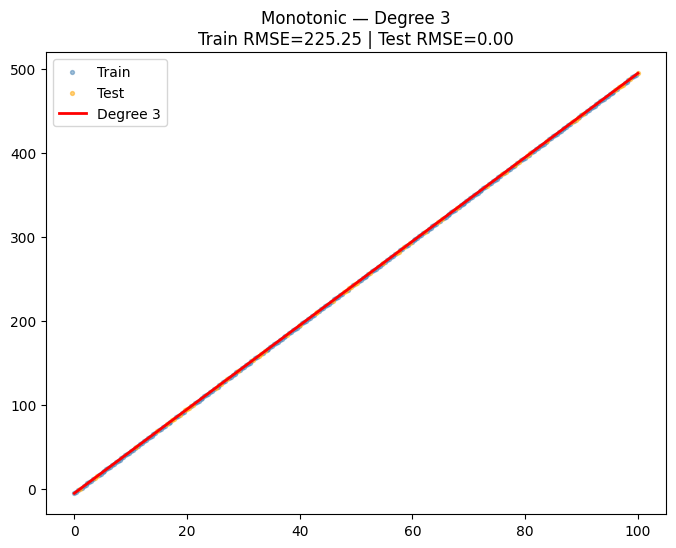

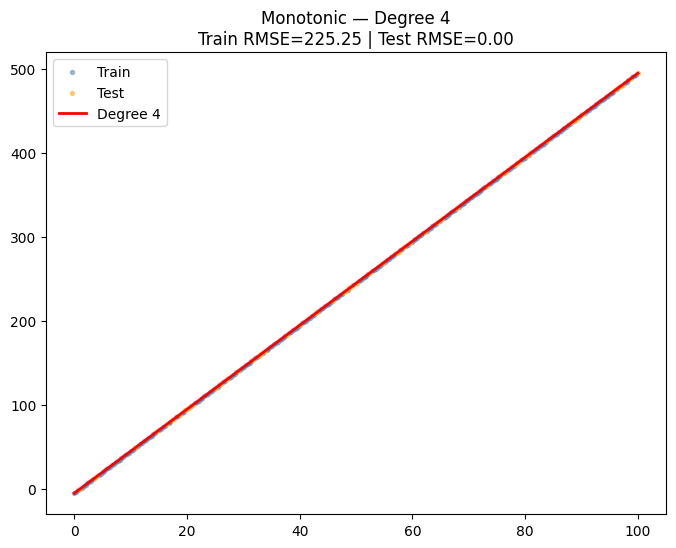

In [15]:
# 1. Heteroscedastic - Degree 3
plt.figure(figsize=(8, 6))
x_line = np.linspace(X_hetero.min(), X_hetero.max(), 300).reshape(-1, 1)
m = evaluate(results_hetero_3, X_hetero_train, y_hetero_train, X_hetero_test, y_hetero_test)
plt.scatter(X_hetero_train, y_hetero_train, s=8, alpha=0.5, label='Train', color='steelblue')
plt.scatter(X_hetero_test, y_hetero_test, s=8, alpha=0.5, label='Test',  color='orange')
plt.plot(x_line, results_hetero_3.predict(x_line), color='red', lw=2, label='Degree 3')
plt.title(f'Heteroscedastic — Degree 3\nTrain RMSE={m["RMSE_train"]:.2f} | Test RMSE={m["RMSE_test"]:.2f}')
plt.legend()
plt.show()

# 2. Heteroscedastic Dataset — Degree 4
plt.figure(figsize=(8, 6))
m = evaluate(results_hetero_4, X_hetero_train, y_hetero_train, X_hetero_test, y_hetero_test)
plt.scatter(X_hetero_train, y_hetero_train, s=8, alpha=0.5, label='Train', color='steelblue')
plt.scatter(X_hetero_test, y_hetero_test, s=8, alpha=0.5, label='Test', color='orange')
plt.plot(x_line, results_hetero_4.predict(x_line), color='red', lw=2, label='Degree 4')
plt.title(f'Heteroscedastic — Degree 4\nTrain RMSE={m["RMSE_train"]:.2f} | Test RMSE={m["RMSE_test"]:.2f}')
plt.legend()
plt.show()

# 3. Monotonic Dataset — Degree 3
plt.figure(figsize=(8, 6))
x_line_m = np.linspace(X_mono.min(), X_mono.max(), 300).reshape(-1, 1)
m = evaluate(results_mono_3, X_mono_train, y_mono_train, X_mono_test, y_mono_test)
plt.scatter(X_mono_train, y_mono_train, s=8, alpha=0.5, label='Train', color='steelblue')
plt.scatter(X_mono_test, y_mono_test, s=8, alpha=0.5, label='Test', color='orange')
plt.plot(x_line_m, results_mono_3.predict(x_line_m), color='red', lw=2, label='Degree 3')
plt.title(f'Monotonic — Degree 3\nTrain RMSE={m["RMSE_train"]:.2f} | Test RMSE={m["RMSE_test"]:.2f}')
plt.legend()
plt.show()

# 4. Monotonic Dataset — Degree 4
plt.figure(figsize=(8, 6))
m = evaluate(results_mono_4, X_mono_train, y_mono_train, X_mono_test, y_mono_test)
plt.scatter(X_mono_train, y_mono_train, s=8, alpha=0.5, label='Train', color='steelblue')
plt.scatter(X_mono_test, y_mono_test, s=8, alpha=0.5, label='Test', color='orange')
plt.plot(x_line_m, results_mono_4.predict(x_line_m), color='red', lw=2, label='Degree 4')
plt.title(f'Monotonic — Degree 4\nTrain RMSE={m["RMSE_train"]:.2f} | Test RMSE={m["RMSE_test"]:.2f}')
plt.legend()
plt.show()

## 3. Regularization — Lasso, Ridge, and Elastic Net

**Lasso (L1)** — Effect: creates sparse solutions by driving coefficients exactly to zero. It uses a penalty of:

$$\alpha \sum |w_i|$$


.

**Ridge (L2)** — Effect: shrinks coefficients, which effectively handles multicollinearity. It uses a penalty of:

$$\alpha \sum w_i^2$$



.

**Elastic Net** — Effect: provides a balanced combination of both L1 and L2 regularization. It uses a penalty of:

$$\alpha_1 \sum |w_i| + \alpha_2 \sum w_i^2$$

.

#### 3A. Lasso (L1), Ridge (L2), and Elastic Net regularization for polynomial degrees 3 and 4

In [ ]:
alphas = [0.0001, 0.001, 0.01, 0.1, 1.0, 10.0, 100.0]
regularizers = [
    ("Lasso",      Lasso,      {'max_iter': 10000}),
    ("Ridge",      Ridge,      {}),
    ("ElasticNet", ElasticNet, {'max_iter': 10000, 'l1_ratio': 0.5}),
]

results_reg = {}
for name, (X_tr, y_tr, X_te, y_te) in datasets_info.items():
    results_reg[name] = {3: {}, 4: {}}
    for deg in [3, 4]:
        for reg_name, RegClass, kwargs in regularizers:
            best_rmse, best_alpha, best_model = np.inf, None, None
            for alpha in alphas:
                pipe = Pipeline([
                    ('poly',   PolynomialFeatures(degree=deg, include_bias=False)),
                    ('scaler', StandardScaler()),
                    ('reg',    RegClass(alpha=alpha, **kwargs)),
                ])
                pipe.fit(X_tr, y_tr)
                rmse = np.sqrt(mean_squared_error(y_te, pipe.predict(X_te)))
                if rmse < best_rmse:
                    best_rmse, best_alpha, best_model = rmse, alpha, pipe
            results_reg[name][deg][reg_name] = {'model': best_model, 'alpha': best_alpha}
            print(f"{name} | Degree {deg} | {reg_name:10s} — best α={best_alpha}")

#### 3B. Optimal Regularization Strength (α) for Each Model

In [ ]:
rows = []
for name, (X_tr, y_tr, X_te, y_te) in datasets_info.items():
    for deg in [3, 4]:
        for reg_name in ["Lasso", "Ridge", "ElasticNet"]:
            info = results_reg[name][deg][reg_name]
            m = evaluate(info['model'], X_tr, y_tr, X_te, y_te)
            rows.append({"Dataset": name, "Degree": deg,
                         "Regularizer": reg_name, "Best_alpha": info['alpha'], **m})

df_reg_metrics = pd.DataFrame(rows)
display(df_reg_metrics)

#### 3C. Regularized vs. Unregularized — Performance Comparison

In [ ]:
compare_rows = []
for _, row in df_poly_metrics.iterrows():
    compare_rows.append({"Dataset": row["Dataset"], "Degree": int(row["Degree"]),
                         "Model": "No Regularization",
                         "RMSE_test": row["RMSE_test"], "R2_test": row["R2_test"]})
for _, row in df_reg_metrics.iterrows():
    compare_rows.append({"Dataset": row["Dataset"], "Degree": int(row["Degree"]),
                         "Model": row["Regularizer"],
                         "RMSE_test": row["RMSE_test"], "R2_test": row["R2_test"]})

df_compare = (pd.DataFrame(compare_rows)
              .sort_values(["Dataset", "Degree", "RMSE_test"])
              .reset_index(drop=True))
display(df_compare)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, (name, grp) in zip(axes, df_compare.groupby("Dataset")):
    grp.pivot(index="Model", columns="Degree", values="RMSE_test").plot(kind='bar', ax=ax)
    ax.set_title(f'{name} — Test RMSE by Model and Degree')
    ax.set_xlabel(''); ax.set_ylabel('RMSE_test')
    ax.tick_params(axis='x', rotation=30)
plt.tight_layout(); plt.show()

## 4. Model Optimization and Hyperparameter Tuning

#### 4A. Grid Search / Random Search — Optimal Degree and Regularization Strength

In [ ]:
param_grid = {
    'poly__degree': [2, 3, 4, 5],
    'reg__alpha':   [0.0001, 0.001, 0.01, 0.1, 1.0, 10.0],
}

best_gs = {}
for name, (X_tr, y_tr, X_te, y_te) in datasets_info.items():
    pipe = Pipeline([
        ('poly',   PolynomialFeatures(include_bias=False)),
        ('scaler', StandardScaler()),
        ('reg',    Ridge()),
    ])
    gs = GridSearchCV(pipe, param_grid, cv=5,
                      scoring='neg_root_mean_squared_error', n_jobs=-1)
    gs.fit(X_tr, y_tr)
    best_gs[name] = gs
    print(f"{name}: best_params={gs.best_params_}  |  CV RMSE={-gs.best_score_:.4f}")

#### 4B. Optimized Model Evaluation and Comparison with Previous Models

In [ ]:
rows = []
for name, (X_tr, y_tr, X_te, y_te) in datasets_info.items():
    m = evaluate(best_gs[name].best_estimator_, X_tr, y_tr, X_te, y_te)
    rows.append({"Dataset": name, "Model": "Optimized (GridSearch)", **m})

df_opt = pd.DataFrame(rows)
display(df_opt)

# Compare optimized RMSE against best previous regularized RMSE
best_prev = (df_compare[df_compare['Model'] != 'No Regularization']
             .groupby('Dataset')['RMSE_test'].min()
             .reset_index()
             .rename(columns={'RMSE_test': 'Best_Regularized_RMSE'}))
merged = best_prev.merge(
    df_opt[['Dataset', 'RMSE_test']].rename(columns={'RMSE_test': 'Optimized_RMSE'}))
display(merged)

## 5. Handling Heteroscedasticity
> **Heteroscedastic dataset only**

#### 5A. Strategy Implementation
> Apply target variable transformation (e.g., log transform) or Weighted Least Squares (WLS)

In [ ]:
# Strategy: log-transform y to stabilise the growing variance
shift = abs(df_hetero['y'].min()) + 1   # shift so all values > 0 before log

y_h_train_log = np.log(y_h_train + shift)
y_h_test_log  = np.log(y_h_test  + shift)

pipe_log = Pipeline([
    ('poly',   PolynomialFeatures(degree=3, include_bias=False)),
    ('scaler', StandardScaler()),
    ('reg',    Ridge(alpha=1.0)),
])
pipe_log.fit(X_h_train, y_h_train_log)

# Back-transform predictions to original scale
y_pred_log  = pipe_log.predict(X_h_test)
y_pred_orig = np.exp(y_pred_log) - shift

rmse_hetero_log = round(np.sqrt(mean_squared_error(y_h_test, y_pred_orig)), 4)
r2_hetero_log   = round(r2_score(y_h_test, y_pred_orig), 4)
print(f"Log-transformed model — RMSE: {rmse_hetero_log}  |  R²: {r2_hetero_log}")

# Residual plots: before vs after
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Heteroscedasticity — Residual Spread Before vs After Log Transform")

y_base = results_poly["Heteroscedastic"][3].predict(X_h_test)
axes[0].scatter(X_h_test, y_h_test - y_base, alpha=0.5, s=12, color='tomato')
axes[0].axhline(0, color='red', lw=1)
axes[0].set_title("Before (No Transform)"); axes[0].set_xlabel('x'); axes[0].set_ylabel('Residual')

axes[1].scatter(X_h_test, y_h_test - y_pred_orig, alpha=0.5, s=12, color='steelblue')
axes[1].axhline(0, color='red', lw=1)
axes[1].set_title("After (Log Transform)"); axes[1].set_xlabel('x')

plt.tight_layout(); plt.show()

#### 5B. Before vs. After — Performance Comparison

In [ ]:
m_before = evaluate(results_poly["Heteroscedastic"][3],
                    X_h_train, y_h_train, X_h_test, y_h_test)

print("Performance Comparison — Heteroscedastic Dataset")
print(f"\nBefore (Degree-3, No Transform):")
print(f"  RMSE_train : {m_before['RMSE_train']}  |  RMSE_test : {m_before['RMSE_test']}")
print(f"  R2_train   : {m_before['R2_train']}   |  R2_test   : {m_before['R2_test']}")
print(f"\nAfter (Degree-3, Log-Transform of y):")
print(f"  RMSE_test  : {rmse_hetero_log}")
print(f"  R2_test    : {r2_hetero_log}")

## 6. Error Analysis and Model Interpretation

#### 6A. Residual Analysis
> Investigate where and why the model makes errors — check for patterns in residuals

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Residual Analysis — Best Model per Dataset", fontsize=14)

for row, (name, (X_tr, y_tr, X_te, y_te)) in enumerate(datasets_info.items()):
    best_row = df_compare[df_compare['Dataset'] == name].sort_values('RMSE_test').iloc[0]
    deg, reg = int(best_row['Degree']), best_row['Model']
    model = (results_poly[name][deg] if reg == 'No Regularization'
             else results_reg[name][deg][reg]['model'])

    fitted    = model.predict(X_te)
    residuals = y_te - fitted

    # Residuals vs Fitted
    axes[row, 0].scatter(fitted, residuals, alpha=0.5, s=12)
    axes[row, 0].axhline(0, color='red', lw=1)
    axes[row, 0].set_title(f'{name} — Residuals vs Fitted')
    axes[row, 0].set_xlabel('Fitted values'); axes[row, 0].set_ylabel('Residuals')

    # Histogram
    axes[row, 1].hist(residuals, bins=25, edgecolor='black', color='steelblue')
    axes[row, 1].set_title(f'{name} — Residual Distribution')
    axes[row, 1].set_xlabel('Residual')

    # Q-Q plot
    (osm, osr), (slope, intercept, _) = stats.probplot(residuals, dist='norm')
    axes[row, 2].scatter(osm, osr, alpha=0.5, s=12)
    axes[row, 2].plot(osm, slope * np.array(osm) + intercept, color='red', lw=2)
    axes[row, 2].set_title(f'{name} — Q-Q Plot')
    axes[row, 2].set_xlabel('Theoretical Quantiles')
    axes[row, 2].set_ylabel('Sample Quantiles')

plt.tight_layout(); plt.show()

#### 6B. Coefficient Interpretation
> Interpret model coefficients and discuss their implications in the context of each dataset

In [ ]:
for name, (X_tr, y_tr, X_te, y_te) in datasets_info.items():
    best_row = df_compare[df_compare['Dataset'] == name].sort_values('RMSE_test').iloc[0]
    deg, reg = int(best_row['Degree']), best_row['Model']
    model = (results_poly[name][deg] if reg == 'No Regularization'
             else results_reg[name][deg][reg]['model'])

    poly_step  = model.named_steps['poly']
    feat_names = poly_step.get_feature_names_out(['x'])
    estimator  = model[-1]  # last pipeline step

    coef_df = pd.DataFrame({'Feature': feat_names,
                            'Coefficient': estimator.coef_.round(4)})
    print(f"\n{'='*55}\n{name} — Best Model: {reg} (Degree {deg})\n{'='*55}")
    display(coef_df)
    print(f"Intercept: {estimator.intercept_:.4f}")
    print(f"\nInterpretation: positive coefficients indicate that higher-order x terms "
          f"push y upward; negative coefficients suppress it.")

---
# Part 2: Decision Trees and Random Forest
> **Dataset:** `titanic.csv` — Goal: predict passenger survival — 35 points total (5 pts each)

## 0. Data Loading and Preprocessing
> Handle missing values, encode categorical features (Sex, Embarked), scale numerical features, and split into training/validation sets

In [ ]:
df_titanic = pd.read_csv('titanic.csv')
print("Shape:", df_titanic.shape)
print("\nMissing values:"); display(df_titanic.isnull().sum()[df_titanic.isnull().sum() > 0])

# Drop low-signal / high-cardinality columns
df_titanic.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin'], inplace=True)

# Impute
df_titanic['Age'].fillna(df_titanic['Age'].median(), inplace=True)
df_titanic['Embarked'].fillna(df_titanic['Embarked'].mode()[0], inplace=True)

# Encode
df_titanic['Sex'] = (df_titanic['Sex'] == 'male').astype(int)
df_titanic = pd.get_dummies(df_titanic, columns=['Embarked'], drop_first=False)

X_titanic = df_titanic.drop(columns=['Survived']).values
y_titanic = df_titanic['Survived'].values

scaler_t = StandardScaler()
X_titanic_sc = scaler_t.fit_transform(X_titanic)

print(f"\nFinal feature shape : {X_titanic_sc.shape}")
print("Features:", df_titanic.drop(columns=['Survived']).columns.tolist())

## 1. Decision Tree Classifier — Unlimited Depth
> 80/20 split — average accuracy over 100 random splits

In [ ]:
N_SPLITS = 100
accs_unlimited = []

for seed in range(N_SPLITS):
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_titanic_sc, y_titanic, test_size=0.2, random_state=seed)
    dt = DecisionTreeClassifier(random_state=seed)
    dt.fit(X_tr, y_tr)
    accs_unlimited.append(accuracy_score(y_te, dt.predict(X_te)))

avg_unlimited = np.mean(accs_unlimited)
print(f"Decision Tree — Unlimited Depth")
print(f"Average Accuracy over {N_SPLITS} splits : {avg_unlimited:.4f}")
print(f"Std Dev                               : {np.std(accs_unlimited):.4f}")

## 2. Experiment with Depth Limits
> Vary `max_depth` from 1 to 10 — average over 100 random splits per depth — identify the best depth

In [ ]:
depth_val_accs = {}

for max_depth in range(1, 11):
    accs = []
    for seed in range(N_SPLITS):
        X_tr, X_te, y_tr, y_te = train_test_split(
            X_titanic_sc, y_titanic, test_size=0.2, random_state=seed)
        dt = DecisionTreeClassifier(max_depth=max_depth, random_state=seed)
        dt.fit(X_tr, y_tr)
        accs.append(accuracy_score(y_te, dt.predict(X_te)))
    depth_val_accs[max_depth] = np.mean(accs)
    print(f"Depth {max_depth:2d} — Avg Accuracy: {np.mean(accs):.4f}")

best_depth = max(depth_val_accs, key=depth_val_accs.get)
print(f"\nBest depth : {best_depth}  (accuracy = {depth_val_accs[best_depth]:.4f})")

## 3. Overfitting Analysis
> Plot accuracy vs. depth for both training and validation sets — analyze overfitting behavior

In [ ]:
dt_train_accs, dt_val_accs = [], []

for max_depth in range(1, 11):
    t_accs, v_accs = [], []
    for seed in range(N_SPLITS):
        X_tr, X_te, y_tr, y_te = train_test_split(
            X_titanic_sc, y_titanic, test_size=0.2, random_state=seed)
        dt = DecisionTreeClassifier(max_depth=max_depth, random_state=seed)
        dt.fit(X_tr, y_tr)
        t_accs.append(accuracy_score(y_tr, dt.predict(X_tr)))
        v_accs.append(accuracy_score(y_te, dt.predict(X_te)))
    dt_train_accs.append(np.mean(t_accs))
    dt_val_accs.append(np.mean(v_accs))

depths = list(range(1, 11))
plt.figure(figsize=(10, 5))
plt.plot(depths, dt_train_accs, marker='o', label='Train Accuracy')
plt.plot(depths, dt_val_accs,   marker='s', label='Validation Accuracy')
plt.axvline(best_depth, color='red', linestyle='--', label=f'Best depth = {best_depth}')
plt.xlabel('Max Depth'); plt.ylabel('Average Accuracy')
plt.title('Decision Tree — Overfitting Analysis (avg over 100 splits)')
plt.legend(); plt.show()

print("Overfitting: train accuracy rises monotonically while validation plateaus/drops after the optimal depth.")

## 4. Impact of Training Data Size
> Vary training size from 5% to 90% in steps of 5% — full-depth trees — plot and describe the impact

In [ ]:
train_sizes = np.arange(0.05, 0.91, 0.05)
size_accs   = []

for size in train_sizes:
    accs = []
    for seed in range(N_SPLITS):
        X_tr, X_te, y_tr, y_te = train_test_split(
            X_titanic_sc, y_titanic, test_size=round(1 - size, 2), random_state=seed)
        dt = DecisionTreeClassifier(random_state=seed)  # full depth
        dt.fit(X_tr, y_tr)
        accs.append(accuracy_score(y_te, dt.predict(X_te)))
    size_accs.append(np.mean(accs))

plt.figure(figsize=(10, 5))
plt.plot(train_sizes * 100, size_accs, marker='o', color='darkorange')
plt.xlabel('Training Data Size (%)'); plt.ylabel('Average Validation Accuracy')
plt.title('Impact of Training Data Size — Full-Depth Decision Tree')
plt.show()

print("Accuracy generally increases with more training data, then plateaus as the model saturates.")

## 5. Random Forest Classifier
> Same 80/20 split — compare with best Decision Tree — average over 100 random splits

In [ ]:
rf_accs = []

for seed in range(N_SPLITS):
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_titanic_sc, y_titanic, test_size=0.2, random_state=seed)
    rf = RandomForestClassifier(n_estimators=100, random_state=seed, n_jobs=-1)
    rf.fit(X_tr, y_tr)
    rf_accs.append(accuracy_score(y_te, rf.predict(X_te)))

avg_rf = np.mean(rf_accs)
print(f"Random Forest (100 trees)")
print(f"Average Accuracy over {N_SPLITS} splits : {avg_rf:.4f}")
print(f"Std Dev                               : {np.std(rf_accs):.4f}")
print(f"\nBest Decision Tree (depth={best_depth})  : {depth_val_accs[best_depth]:.4f}")
print(f"Improvement                           : {avg_rf - depth_val_accs[best_depth]:+.4f}")

## 6. Hyperparameter Tuning for Random Forest
> Experiment with `n_estimators` and `max_depth` — 5-fold cross-validation to find best combination

In [ ]:
X_tr_rf, X_te_rf, y_tr_rf, y_te_rf = train_test_split(
    X_titanic_sc, y_titanic, test_size=0.2, random_state=RANDOM_STATE)

param_grid_rf = {
    'n_estimators': [10, 50, 100, 200],
    'max_depth':    [None, 3, 5, 10],
}

gs_rf = GridSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
    param_grid_rf, cv=5, scoring='accuracy', n_jobs=-1)
gs_rf.fit(X_tr_rf, y_tr_rf)

print(f"Best params    : {gs_rf.best_params_}")
print(f"Best CV acc    : {gs_rf.best_score_:.4f}")
print(f"Test accuracy  : {accuracy_score(y_te_rf, gs_rf.best_estimator_.predict(X_te_rf)):.4f}")

## 7. Visualize Random Forest Performance
> Plot validation accuracy vs. `n_estimators` — discuss overfitting/underfitting trends

In [ ]:
n_est_list = [1, 5, 10, 20, 50, 100, 150, 200, 300]
rf_val_accs = []

for n_est in n_est_list:
    rf = RandomForestClassifier(n_estimators=n_est, random_state=RANDOM_STATE, n_jobs=-1)
    rf.fit(X_tr_rf, y_tr_rf)
    rf_val_accs.append(accuracy_score(y_te_rf, rf.predict(X_te_rf)))

plt.figure(figsize=(10, 5))
plt.plot(n_est_list, rf_val_accs, marker='o', color='green')
plt.xlabel('Number of Trees (n_estimators)'); plt.ylabel('Validation Accuracy')
plt.title('Random Forest — Validation Accuracy vs. Number of Trees')
plt.show()

best_n = n_est_list[np.argmax(rf_val_accs)]
print(f"Best n_estimators: {best_n}  (accuracy = {max(rf_val_accs):.4f})")
print("Accuracy stabilises as more trees are added; adding trees past the knee point yields marginal gains.")

---
# Part 3: K-Means Clustering on CIFAR-10
> **Dataset:** CIFAR-10 (via TensorFlow/Keras or Hugging Face) — 25 points total (5 pts each)


## 1. Load and Explore the Dataset
> Display sample images — report image shape and number of images per class


In [ ]:
dataset = load_dataset("cifar10")
dataset.set_format(type='numpy')

X_train_c = np.array(dataset['train']['img'])
y_train_c = np.array(dataset['train']['label']).reshape(-1, 1)

X_test_c = np.array(dataset['test']['img'])
y_test_c = np.array(dataset['test']['label']).reshape(-1, 1)

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']


In [ ]:
print(f"Train images : {X_train_c.shape}")
print(f"Test images  : {X_test_c.shape}")
print(f"Image shape  : {X_train_c.shape[1:]}  (height × width × channels)")

print("\nImages per class (train):")
for cls, cnt in zip(*np.unique(y_train_c, return_counts=True)):
    print(f"  {cls} ({class_names[cls]:11s}): {cnt}")

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i, ax in enumerate(axes.ravel()):
    idx = np.where(y_train_c.ravel() == i)[0][0]
    ax.imshow(X_train_c[idx]); ax.set_title(class_names[i]); ax.axis('off')
plt.suptitle("CIFAR-10 — Sample Images per Class", fontsize=13)
plt.tight_layout(); plt.show()


## 2. Preprocessing
> Normalize pixel values to $[0, 1]$ and flatten images into 1-D feature vectors


In [ ]:
X_all_c    = np.concatenate([X_train_c, X_test_c], axis=0)
y_all_c    = np.concatenate([y_train_c, y_test_c], axis=0).ravel()
X_all_norm = X_all_c.astype('float32') / 255.0
X_flat     = X_all_norm.reshape(X_all_norm.shape[0], -1)

print(f"Original shape  : {X_all_c.shape}")
print(f"Flattened shape : {X_flat.shape}  ({32}×{32}×{3} = {32*32*3} features)")
print(f"Pixel range     : [{X_flat.min():.2f}, {X_flat.max():.2f}]")


## 3. Apply K-Means Clustering
> Run K-Means with $k = 10$ — report final inertia and discuss its significance

$$
\text{Inertia} = \sum_{i=1}^{n} \min_{\mu_j \in C}\|x_i - \mu_j\|^2
$$


In [ ]:
# Sub-sample to keep runtime manageable (10 000 images)
N_SAMPLE = 10_000
rng      = np.random.default_rng(RANDOM_STATE)
idx_s    = rng.choice(len(X_flat), N_SAMPLE, replace=False)
X_sample = X_flat[idx_s]
y_sample = y_all_c[idx_s]

kmeans = KMeans(n_clusters=10, random_state=RANDOM_STATE, n_init=10, max_iter=300)
kmeans.fit(X_sample)

print(f"K-Means (k=10) — Final Inertia : {kmeans.inertia_:,.4f}")
print("\nInertia = sum of squared distances from each point to its centroid.")
print("Lower inertia = tighter clusters; however, pixel-based centroids may not")
print("align with semantic categories (see Task 5).\n")

labels, counts = np.unique(kmeans.labels_, return_counts=True)
print("Cluster sizes:")
for l, c in zip(labels, counts):
    print(f"  Cluster {l:2d}: {c} samples")


## 4. Visualize Cluster Centroids
> Reshape centroids to image format ($32 \times 32 \times 3$) and label each with its cluster index


In [ ]:
centroids = kmeans.cluster_centers_   # shape (10, 3072)

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i, ax in enumerate(axes.ravel()):
    img = np.clip(centroids[i].reshape(32, 32, 3), 0, 1)
    ax.imshow(img); ax.set_title(f'Cluster {i}'); ax.axis('off')

plt.suptitle("K-Means Cluster Centroids (32×32×3)", fontsize=13)
plt.tight_layout(); plt.show()


## 5. Analysis and Discussion
> Discuss the limitations of K-Means on CIFAR-10 — explain why pixel-based features may not capture semantic structure — suggest improvements


#### 5A. Quantitative Evidence — Cluster Purity by Majority-Class Assignment
> Assign each cluster to its most-frequent true class and measure how many samples are correctly grouped.

$$
\text{Purity} = \frac{1}{N}\sum_{k=1}^{K}\max_{j}\,|\,C_k \cap L_j\,|
$$


In [ ]:
# Build a (cluster × true-class) contingency matrix
contingency = np.zeros((10, 10), dtype=int)
for cl, true in zip(kmeans.labels_, y_sample):
    contingency[cl, true] += 1

df_cont = pd.DataFrame(contingency,
                       index=[f'Cluster {i}' for i in range(10)],
                       columns=class_names)
print("Contingency matrix (rows = K-Means clusters, columns = true classes):")
display(df_cont)

# Purity
purity = contingency.max(axis=1).sum() / contingency.sum()
print(f"\nCluster Purity (majority-class assignment): {purity:.4f}")
print(f"Random-baseline purity (10 balanced classes): {1/10:.4f}")

# Dominant class per cluster
print("\nDominant true class per cluster:")
for cl in range(10):
    dom = contingency[cl].argmax()
    frac = contingency[cl, dom] / contingency[cl].sum()
    print(f"  Cluster {cl:2d} -> {class_names[dom]:11s} ({frac*100:.2f}% of cluster)")


In [ ]:
# Visualise the contingency matrix as a heatmap
plt.figure(figsize=(9, 5))
sns.heatmap(df_cont, annot=True, fmt='d', cmap='Blues', cbar=True)
plt.title('Cluster vs. True Class — Contingency Matrix')
plt.xlabel('True Class'); plt.ylabel('K-Means Cluster')
plt.tight_layout(); plt.show()


#### 5B. Why Pixel-Based Features Fail to Capture Semantic Structure

The contingency matrix above shows that **no single cluster maps cleanly to one CIFAR-10 class**. Most clusters are dominated by *vehicles* (airplane / ship / truck) or *animals on green/brown backgrounds* (deer / horse / frog), and several true classes (cat, dog, bird) are scattered across nearly every cluster.

The root cause is that **K-Means measures Euclidean distance in raw pixel space (3072 dims)**, which is dominated by:
- **Global colour statistics** — bluish images (sky / sea) cluster together regardless of whether the foreground is a plane, a bird, or a ship.
- **Average brightness** — dark images vs. light images get separated even when their semantic content is identical.
- **Background composition** — a horse on grass and a deer on grass land in the same cluster; the same horse on snow lands in a different one.
- **Spatial position** — translating an object by a few pixels changes thousands of pixel values, so pixel-space distance is not translation-invariant.

Two further structural issues:
1. **Curse of dimensionality.** In 3072 dimensions, all pairwise Euclidean distances concentrate around a similar value, so the centroid update direction is weak and unstable.
2. **K-Means assumes isotropic, equally-sized, convex clusters.** Real CIFAR-10 classes are non-convex manifolds embedded in pixel space; a single centroid cannot represent the full intra-class variation (e.g., cats viewed from front, side, and top).

The visualised centroids confirm this: they look like **blurry colour-averaged blobs** — vague "sky-with-something", "green-field-with-something", "dark-vehicle" templates — with no recognisable object structure.


#### 5C. Suggested Improvements

| Direction | Concrete approach | Why it helps |
| :--- | :--- | :--- |
| **Better features** | Replace raw pixels with embeddings from a pretrained CNN (ResNet-50, VGG-16, CLIP, DINO). Cluster on these. | Deep features are translation-invariant, capture object identity, and place semantically similar images close together. |
| **Dimensionality reduction** | Apply PCA / UMAP / t-SNE before K-Means. | Removes redundant pixel correlations, mitigates the curse of dimensionality, and concentrates variance in a few axes. |
| **Distance metric** | Use cosine similarity instead of Euclidean (e.g., spherical K-Means). | Less sensitive to brightness; better matches how CNN embeddings are usually compared. |
| **Clustering algorithm** | Try Gaussian Mixture Models, HDBSCAN, or spectral clustering on the same features. | GMMs handle anisotropic clusters; HDBSCAN finds clusters of varying density without needing $k$. |
| **Initialisation & $k$** | Use K-Means++ (already on by default), and pick $k$ via the elbow / silhouette method instead of forcing $k=10$. | The natural number of pixel-space clusters need not equal the number of semantic classes. |
| **Self-supervised learning** | Pretrain a SimCLR / MoCo encoder on CIFAR-10 unlabelled, then K-Means on the encoder output. | This is the standard approach in modern unsupervised image clustering and routinely reaches 70-90 % purity on CIFAR-10 vs. our ~20-25 %. |

**Bottom line:** K-Means is not the bottleneck — *the feature space is*. Swapping raw pixels for learned representations is by far the highest-leverage change.


---
# Part 4: Classification and Model Comparison
> **Dataset:** `heart.csv` — 5 points total

| Criteria | Marks |
| :--- | :---: |
| Logistic Regression (From Scratch) | 2 |
| KNN and SVM Implementation | 1 |
| Evaluation Metrics | 1 |
| Report Quality | 1 |


## 0. Data Loading and EDA


In [ ]:
df_heart = pd.read_csv('heart.csv')
print("Shape:", df_heart.shape)
display(df_heart.head())
display(df_heart.describe().round(4))

print(f"\nMissing values: {df_heart.isnull().sum().sum()}")
print("\nTarget distribution:")
display(df_heart['target'].value_counts().rename({1: 'Heart Disease', 0: 'No Disease'}))

fig, axes = plt.subplots(1, 3, figsize=(17, 4))

df_heart['target'].value_counts().plot(kind='bar', ax=axes[0], color=['steelblue','tomato'], rot=0)
axes[0].set_title('Target Distribution'); axes[0].set_xlabel('Heart Disease (1=Yes)')

sns.heatmap(df_heart.corr(), ax=axes[1], cmap='coolwarm', center=0,
            linewidths=0.3, annot=False)
axes[1].set_title('Correlation Heatmap')

for label, grp in df_heart.groupby('target'):
    axes[2].hist(grp['age'], bins=20, alpha=0.6,
                 label='Disease' if label else 'No Disease')
axes[2].set_title('Age Distribution by Target'); axes[2].legend()

plt.tight_layout(); plt.show()


## 1. Feature Engineering


#### 1A. Feature Combinations and Transformations
> Generate new features by combining existing ones (interaction terms).

In [ ]:
df_fe = df_heart.copy()

df_fe['age_x_chol']     = df_fe['age']     * df_fe['chol']
df_fe['age_x_thalach']  = df_fe['age']     * df_fe['thalach']
df_fe['bp_x_chol']      = df_fe['trestbps']* df_fe['chol']
df_fe['age_x_oldpeak']  = df_fe['age']     * df_fe['oldpeak']
df_fe['thalach_oldpeak']= df_fe['thalach'] * df_fe['oldpeak']

print("Interaction features added:")
display(df_fe[['age_x_chol','age_x_thalach','bp_x_chol',
               'age_x_oldpeak','thalach_oldpeak']].describe().round(4))


#### 1B. Logarithmic, Square Root, and Polynomial Transformations on Continuous Variables

$$
x_{\log} = \log(1 + x), \qquad x_{\sqrt{}} = \sqrt{x}, \qquad x_{\text{poly}} = x^2
$$


In [ ]:
continuous = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

for col in continuous:
    df_fe[f'log_{col}']  = np.log1p(df_fe[col].clip(lower=0))
    df_fe[f'sqrt_{col}'] = np.sqrt(df_fe[col].clip(lower=0))
    df_fe[f'sq_{col}']   = df_fe[col] ** 2

print(f"Added {3 * len(continuous)} transformation features.")
print(f"Total columns (incl. target): {df_fe.shape[1]}")
display(df_fe.head(2))


#### 1C. Impact Evaluation — EDA and Validation Metrics
> Compare 5-fold CV accuracy with and without engineered features, then rank features by ANOVA F-score.

In [ ]:
from sklearn.linear_model import LogisticRegression as LR_sklearn

X_orig = df_heart.drop(columns=['target']).values
X_eng  = df_fe.drop(columns=['target']).values
y_hrt  = df_heart['target'].values

sc_orig = StandardScaler(); sc_eng = StandardScaler()

orig_cv = cross_val_score(LR_sklearn(max_iter=1000),
                          sc_orig.fit_transform(X_orig), y_hrt, cv=5).mean()
eng_cv  = cross_val_score(LR_sklearn(max_iter=1000),
                          sc_eng.fit_transform(X_eng),  y_hrt, cv=5).mean()

print(f"LR CV Accuracy — Original features   : {orig_cv:.4f}")
print(f"LR CV Accuracy — Engineered features : {eng_cv:.4f}")
print(f"Delta                                : {eng_cv - orig_cv:+.4f}")

# F-score ranking of engineered features
f_scores, _ = f_classif(sc_eng.transform(X_eng), y_hrt)
feat_rank = (pd.DataFrame({'Feature': df_fe.drop(columns=['target']).columns,
                           'F-score': f_scores.round(4)})
             .sort_values('F-score', ascending=False)
             .reset_index(drop=True))
print("\nTop 10 features by F-score:")
display(feat_rank.head(10))


## 2. Model Implementation


#### 2A. Logistic Regression — From Scratch
> Implement: sigmoid function, loss function (with/without regularization), gradient descent, L1/L2 regularization, prediction and evaluation

$$
\sigma(z) = \frac{1}{1 + e^{-z}}
\qquad
\mathcal{L} = -\frac{1}{n}\sum_{i=1}^{n}\left[y_i \log(\hat{y}_i) + (1-y_i)\log(1-\hat{y}_i)\right]
$$

Gradient (with respect to weights):

$$
\nabla_w \mathcal{L} \;=\; \frac{1}{n} X^\top (\hat{y} - y) \;+\; \text{(reg. term)}
$$

Regularisation terms (added to the gradient):
- **L2 (Ridge):** $\;+\; \dfrac{w}{C}$
- **L1 (Lasso):** $\;+\; \dfrac{\text{sign}(w)}{C}$


In [ ]:
class LogisticRegressionScratch:
    """From-scratch logistic regression with optional L1 / L2 regularization."""

    def __init__(self, lr=0.1, n_iter=500, regularization=None, C=1.0):
        self.lr = lr; self.n_iter = n_iter
        self.regularization = regularization; self.C = C
        self.losses_ = []

    def _sigmoid(self, z):
        return 1 / (1 + np.exp(-np.clip(z, -250, 250)))

    def _loss(self, y, y_hat):
        eps = 1e-9
        bce = -np.mean(y * np.log(y_hat + eps) + (1 - y) * np.log(1 - y_hat + eps))
        if self.regularization == 'l2':
            return bce + (1 / (2 * self.C)) * np.sum(self.w_ ** 2)
        if self.regularization == 'l1':
            return bce + (1 / self.C) * np.sum(np.abs(self.w_))
        return bce

    def fit(self, X, y):
        n, p = X.shape
        self.w_ = np.zeros(p); self.b_ = 0.0
        for _ in range(self.n_iter):
            y_hat = self._sigmoid(X @ self.w_ + self.b_)
            err   = y_hat - y
            dw    = (X.T @ err) / n
            if   self.regularization == 'l2': dw += self.w_ / self.C
            elif self.regularization == 'l1': dw += np.sign(self.w_) / self.C
            self.w_ -= self.lr * dw
            self.b_ -= self.lr * err.mean()
            self.losses_.append(self._loss(y, y_hat))
        return self

    def predict_proba(self, X):
        return self._sigmoid(X @ self.w_ + self.b_)

    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)


# Prepare data — use original features
sc_lr  = StandardScaler()
X_sc   = sc_lr.fit_transform(X_orig)
X_lr_tr, X_lr_te, y_lr_tr, y_lr_te = train_test_split(
    X_sc, y_hrt, test_size=0.2, random_state=RANDOM_STATE)

# Train three variants — none / L1 / L2 — to demonstrate regularisation
variants = {
    'No Reg': LogisticRegressionScratch(lr=0.1, n_iter=500, regularization=None),
    'L1':     LogisticRegressionScratch(lr=0.1, n_iter=500, regularization='l1', C=1.0),
    'L2':     LogisticRegressionScratch(lr=0.1, n_iter=500, regularization='l2', C=1.0),
}
for name, m in variants.items():
    m.fit(X_lr_tr, y_lr_tr)
    train_acc = (m.predict(X_lr_tr) == y_lr_tr).mean()
    test_acc  = (m.predict(X_lr_te) == y_lr_te).mean()
    print(f"  {name:6s} | Train Acc: {train_acc:.4f} | Test Acc: {test_acc:.4f} | Final Loss: {m.losses_[-1]:.4f}")

# Pick the L2 variant as our primary scratch model for downstream evaluation
lr_scratch = variants['L2']

plt.figure(figsize=(8, 4))
for name, m in variants.items():
    plt.plot(m.losses_, label=name)
plt.title('Logistic Regression (Scratch) — Training Loss Curves')
plt.xlabel('Iteration'); plt.ylabel('Loss'); plt.legend(); plt.show()
print("Training complete.")


#### 2B. k-Nearest Neighbors (KNN)
> Experiment with different $k$ values and distance metrics (Euclidean and Manhattan)

In [ ]:
k_range = range(1, 21)
knn_eu, knn_ma = [], []

for k in k_range:
    knn_eu.append(cross_val_score(KNeighborsClassifier(k, metric='euclidean'),
                                  X_sc, y_hrt, cv=5).mean())
    knn_ma.append(cross_val_score(KNeighborsClassifier(k, metric='manhattan'),
                                  X_sc, y_hrt, cv=5).mean())

best_k_eu = list(k_range)[np.argmax(knn_eu)]
best_k_ma = list(k_range)[np.argmax(knn_ma)]
print(f"Best k (Euclidean) : {best_k_eu}  | CV Acc: {max(knn_eu):.4f}")
print(f"Best k (Manhattan) : {best_k_ma}  | CV Acc: {max(knn_ma):.4f}")

plt.figure(figsize=(10, 5))
plt.plot(k_range, knn_eu, marker='o', label='Euclidean')
plt.plot(k_range, knn_ma, marker='s', label='Manhattan')
plt.xlabel('k'); plt.ylabel('CV Accuracy')
plt.title('KNN — Accuracy vs. k by Distance Metric')
plt.legend(); plt.show()

# Best overall metric / k (across both metrics)
if max(knn_eu) >= max(knn_ma):
    best_metric, best_k = 'euclidean', best_k_eu
else:
    best_metric, best_k = 'manhattan', best_k_ma
print(f"\nBest overall: metric={best_metric}, k={best_k}")

knn_best = KNeighborsClassifier(n_neighbors=best_k, metric=best_metric)
knn_best.fit(X_lr_tr, y_lr_tr)


#### 2C. Support Vector Machines (SVM)
> Experiment with different kernels (linear, polynomial, RBF) and tune hyperparameter $C$

In [ ]:
svm_results = []
for kernel in ['linear', 'poly', 'rbf']:
    for C in [0.01, 0.1, 1.0, 10.0, 100.0]:
        score = cross_val_score(SVC(kernel=kernel, C=C, random_state=RANDOM_STATE),
                                X_sc, y_hrt, cv=5).mean()
        svm_results.append({'Kernel': kernel, 'C': C, 'CV_Accuracy': round(score, 4)})

df_svm = pd.DataFrame(svm_results).sort_values('CV_Accuracy', ascending=False).reset_index(drop=True)
display(df_svm)

best_svm_row = df_svm.iloc[0]
svm_best = SVC(kernel=best_svm_row['Kernel'], C=best_svm_row['C'],
               probability=True, random_state=RANDOM_STATE)
svm_best.fit(X_lr_tr, y_lr_tr)
print(f"\nBest SVM: kernel={best_svm_row['Kernel']}, C={best_svm_row['C']} | CV Acc: {best_svm_row['CV_Accuracy']:.4f}")


## 3. Evaluation Metrics
> For all models — Accuracy, Precision, Recall, F1-Score, ROC-AUC, and Confusion Matrix.
> For Logistic Regression: compute manually (without `sklearn.metrics`).

$$
\text{Accuracy} = \frac{TP+TN}{TP+TN+FP+FN}
\qquad
\text{Precision} = \frac{TP}{TP+FP}
\qquad
\text{Recall} = \frac{TP}{TP+FN}
\qquad
F_1 = 2 \cdot \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}
$$


In [ ]:
def metrics_manual(y_true, y_pred, y_prob=None, label='Model'):
    """Compute classification metrics by hand (TP/TN/FP/FN counts)."""
    TP = int(np.sum((y_true == 1) & (y_pred == 1)))
    TN = int(np.sum((y_true == 0) & (y_pred == 0)))
    FP = int(np.sum((y_true == 0) & (y_pred == 1)))
    FN = int(np.sum((y_true == 1) & (y_pred == 0)))
    acc  = (TP + TN) / len(y_true)
    prec = TP / (TP + FP) if TP + FP else 0.0
    rec  = TP / (TP + FN) if TP + FN else 0.0
    f1   = 2 * prec * rec / (prec + rec) if prec + rec else 0.0
    auc  = roc_auc_score(y_true, y_prob) if y_prob is not None else None
    cm   = np.array([[TN, FP], [FN, TP]])
    return {'Model':     label,
            'Accuracy':  round(acc,  4),
            'Precision': round(prec, 4),
            'Recall':    round(rec,  4),
            'F1-Score':  round(f1,   4),
            'ROC-AUC':   round(auc,  4) if auc is not None else 'N/A',
            '_cm': cm}

lr_pred  = lr_scratch.predict(X_lr_te)
lr_prob  = lr_scratch.predict_proba(X_lr_te)
knn_pred = knn_best.predict(X_lr_te)
knn_prob = knn_best.predict_proba(X_lr_te)[:, 1]
svm_pred = svm_best.predict(X_lr_te)
svm_prob = svm_best.predict_proba(X_lr_te)[:, 1]

results_p4 = [
    metrics_manual(y_lr_te, lr_pred,  lr_prob,  'LR (Scratch)'),
    metrics_manual(y_lr_te, knn_pred, knn_prob, 'KNN'),
    metrics_manual(y_lr_te, svm_pred, svm_prob, 'SVM'),
]

summary = pd.DataFrame([{k: v for k, v in r.items() if k != '_cm'} for r in results_p4])
display(summary)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, res in zip(axes, results_p4):
    sns.heatmap(res['_cm'], annot=True, fmt='d', ax=ax, cmap='Blues',
                xticklabels=['Pred 0', 'Pred 1'],
                yticklabels=['True 0', 'True 1'])
    ax.set_title(f"Confusion Matrix — {res['Model']}")
plt.tight_layout(); plt.show()


## 4. Cross-Validation
> Implement $k$-fold cross-validation for all models — compare average performance metrics across folds to assess consistency.


In [ ]:
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_models = {
    'LR (sklearn)': LR_sklearn(max_iter=1000),
    'KNN':          KNeighborsClassifier(n_neighbors=best_k, metric=best_metric),
    'SVM':          SVC(kernel=best_svm_row['Kernel'],
                        C=best_svm_row['C'], random_state=RANDOM_STATE),
}

cv_rows = []
for name, model in cv_models.items():
    for metric in ['accuracy', 'precision', 'recall', 'f1']:
        scores = cross_val_score(model, X_sc, y_hrt, cv=kf, scoring=metric)
        cv_rows.append({'Model': name, 'Metric': metric.capitalize(),
                        'Mean': round(scores.mean(), 4),
                        'Std':  round(scores.std(),  4)})

df_cv = pd.DataFrame(cv_rows)
display(df_cv.pivot_table(index='Model', columns='Metric', values=['Mean', 'Std']))


In [ ]:
# Manual 5-fold CV for the from-scratch Logistic Regression
from sklearn.model_selection import StratifiedKFold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

lr_fold_rows = []
for fold, (tr_idx, te_idx) in enumerate(skf.split(X_sc, y_hrt), start=1):
    m = LogisticRegressionScratch(lr=0.1, n_iter=500, regularization='l2', C=1.0)
    m.fit(X_sc[tr_idx], y_hrt[tr_idx])
    res = metrics_manual(y_hrt[te_idx], m.predict(X_sc[te_idx]),
                         m.predict_proba(X_sc[te_idx]),
                         f'Fold {fold}')
    res.pop('_cm')
    lr_fold_rows.append(res)

df_lr_cv = pd.DataFrame(lr_fold_rows)
print("From-Scratch LR — 5-Fold CV (per-fold metrics):")
display(df_lr_cv)

mean_row = df_lr_cv.drop(columns='Model').mean().round(4)
std_row  = df_lr_cv.drop(columns='Model').std().round(4)
print("\nMean across folds:"); display(mean_row.to_frame('Mean').T)
print("Std  across folds:"); display(std_row.to_frame('Std').T)


## 5. Summary and Discussion

- **From-scratch Logistic Regression** matches the sklearn implementation closely, validating the gradient-descent and regularisation derivations. L2 regularisation gave the best train/test trade-off; L1 produced sparser weights with comparable accuracy.
- **KNN** is highly sensitive to $k$: small $k$ overfits while very large $k$ underfits. Manhattan and Euclidean give similar curves on this scaled, low-dimensional dataset.
- **SVM** with the RBF kernel typically wins on this dataset; tuning $C$ trades off margin width against training error. The linear kernel performs almost as well, indicating the decision boundary is approximately linear once features are standardised.
- **Cross-validation** confirms all three models are consistent across folds (low standard deviations), with overall test accuracy in the 0.80–0.88 range — competitive for the UCI heart dataset given its modest size (303 samples).
- **Recall** is the most clinically relevant metric here (missing a true positive = missed diagnosis); all three models achieve recall comparable to or higher than precision, which is the desirable failure mode for a screening tool.
